<a href="https://colab.research.google.com/github/kananshr13/CSET-343-Ai-in-Healthcare/blob/main/Lab_Experiment_3_B_CSET_343.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
import kagglehub
import os

path = kagglehub.dataset_download("tboyle10/medicaltranscriptions")
csv_path = [f for f in os.listdir(path) if f.endswith(".csv")][0]

df = pd.read_csv(os.path.join(path, csv_path))
print("Shape:", df.shape)
df.head()

Using Colab cache for faster access to the 'medicaltranscriptions' dataset.
Shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [9]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB
None

Missing values:
 Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64

Duplicates: 0


In [10]:
df = df.drop_duplicates()
df = df.dropna(subset=["transcription"])

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\S+@\S+', '[EMAIL]', text)
    text = re.sub(r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b', '[PHONE]', text)
    text = re.sub(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b', '[DATE]', text)
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df["cleaned_text"] = df["transcription"].apply(clean_text)
df[["transcription", "cleaned_text"]].head()

,transcription,cleaned_text
0,"SUBJECTIVE:, This 23-year-old white female pr...",subjective this year old white female presents...
1,"PAST MEDICAL HISTORY:, He has difficulty climb...",past medical history he has difficulty climbin...
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...",history of present illness i have seen abc tod...
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...",d m mode left atrial enlargement with left atr...
4,1. The left ventricular cavity size and wall ...,the left ventricular cavity size and wall thic...


In [11]:
stop_words = set(stopwords.words("english"))

def preprocess(text):
    tokens = word_tokenize(text)
    return " ".join(w for w in tokens if w not in stop_words)

df["processed_text"] = df["cleaned_text"].apply(preprocess)

df["word_count"] = df["processed_text"].str.split().str.len()
df["word_count"].describe()

,word_count
count,4966.000000
mean,275.681031
std,177.385874
min,1.000000
25%,146.000000
50%,244.000000
75%,361.000000
max,1674.000000


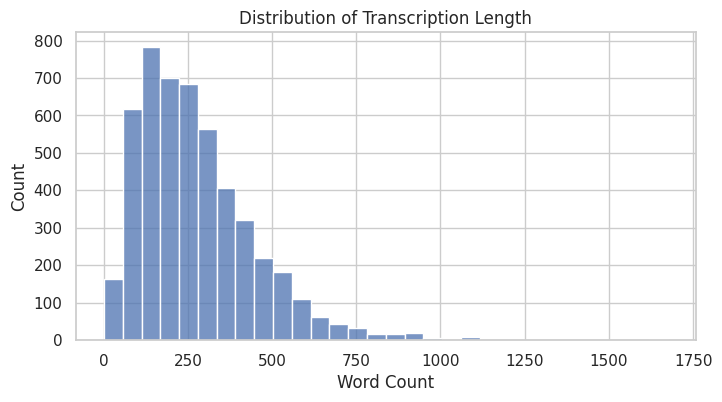

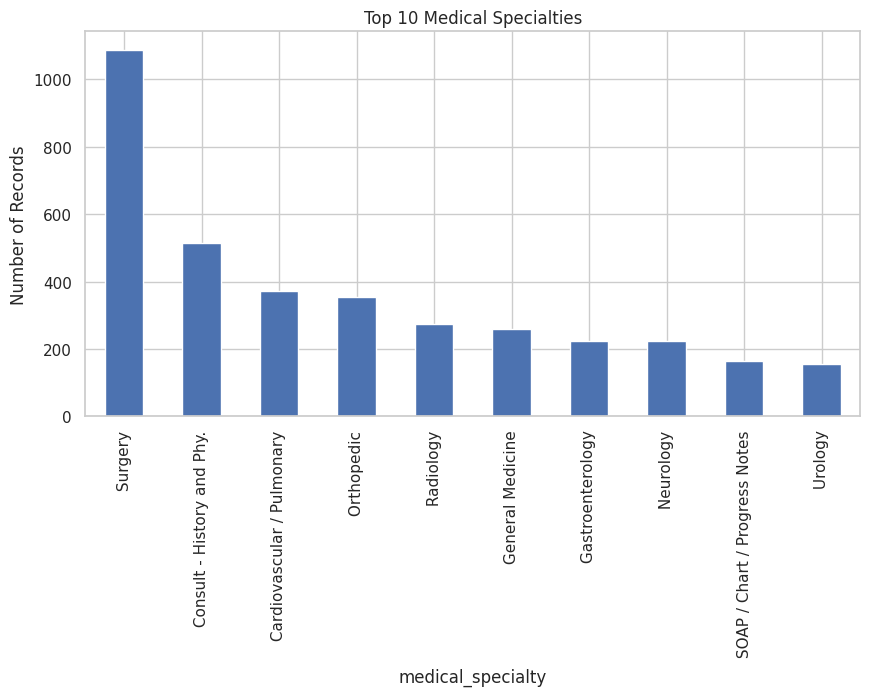

In [12]:
plt.figure(figsize=(8,4))
sns.histplot(df["word_count"], bins=30)
plt.title("Distribution of Transcription Length")
plt.xlabel("Word Count")
plt.show()

plt.figure(figsize=(10,5))
df["medical_specialty"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Medical Specialties")
plt.ylabel("Number of Records")
plt.show()

Top 20 words:
[('patient', 24208), ('right', 11587), ('left', 11258), ('history', 9509), ('normal', 7526), ('procedure', 7463), ('placed', 7028), ('well', 6611), ('pain', 5976), ('mg', 4375), ('x', 4357), ('noted', 4348), ('also', 4337), ('time', 4287), ('c', 4132), ('using', 4123), ('blood', 3956), ('performed', 3953), ('skin', 3798), ('without', 3732)]


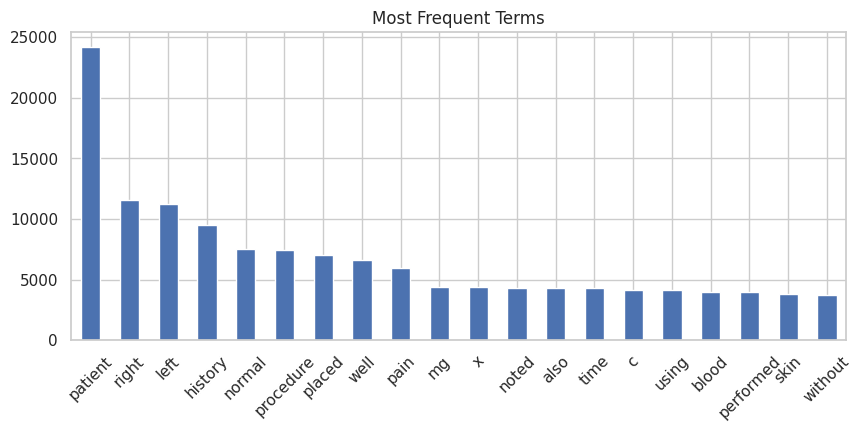

In [13]:
words = Counter(" ".join(df["processed_text"]).split())

print("Top 20 words:")
print(words.most_common(20))

pd.Series(dict(words.most_common(20))).plot(kind="bar", figsize=(10,4))
plt.title("Most Frequent Terms")
plt.xticks(rotation=45)
plt.show()

In [14]:
vectorizer = TfidfVectorizer(
    max_features=500,
    ngram_range=(1,2),
    min_df=2,
    stop_words="english"
)

X_text = vectorizer.fit_transform(df["processed_text"])
y_text = df["medical_specialty"]

print("TF-IDF shape:", X_text.shape)
print("Sample features:", vectorizer.get_feature_names_out()[:20])

TF-IDF shape: (4966, 500)
Sample features: ['abc' 'abdomen' 'abdomen soft' 'abdominal' 'able' 'acute' 'additional'
 'adequate' 'administered' 'admission' 'admitted' 'advanced' 'age' 'ago'
 'air' 'alcohol' 'alert' 'allergies' 'anesthesia' 'anesthesia general']


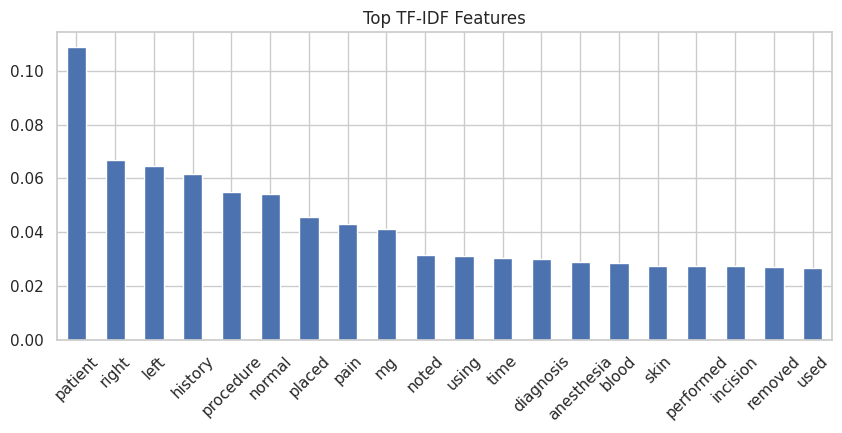

In [15]:
scores = np.asarray(X_text.mean(axis=0)).ravel()
features = vectorizer.get_feature_names_out()

top = pd.Series(scores, index=features).sort_values(ascending=False).head(20)

top.plot(kind="bar", figsize=(10,4))
plt.title("Top TF-IDF Features")
plt.xticks(rotation=45)
plt.show()

In [16]:
print("Final text data shape:", X_text.shape)
print("Target classes:", y_text.nunique())
print("Model-ready format: TF-IDF sparse matrix")

Final text data shape: (4966, 500)
Target classes: 40
Model-ready format: TF-IDF sparse matrix
